# Do Neighborhoods with Higher Housing Burden Also Have Higher Crime Rates?

**URSP688Y Urban Data Science & Smart Cities**  
**Final Project**  
**Study area:** Prince George's County, Maryland

This notebook examines whether census tracts with higher renter housing burden also experience higher crime rates in Prince George's County. The analysis combines 2024 crime incident data, ACS 2020-2024 tract-level socioeconomic data, and Census TIGER/Line tract boundaries.


## 1. Research Question and Analytical Approach

**Main research question:**  
Do census tracts with higher housing burden also experience higher crime rates?

**Sub-questions:**
1. Do census tracts with higher housing burden also experience higher crime rates?
2. Which areas in Prince George’s County show both high housing burden and high crime most strongly?
3. Do violent crime and property crime show different patterns?

**Analytical workflow:**
1. Load ACS, crime incident, and census tract boundary data.
2. Clean and classify crime incidents into violent and property crime categories.
3. Convert crime records into spatial points using the provided latitude and longitude coordinates.
4. Assign crime incidents to census tracts using a point-in-polygon spatial join.
5. Aggregate crime incidents to the tract level.
6. Calculate crime rates per 1,000 residents.
7. Merge tract-level crime measures with ACS housing burden data.
8. Compare mean crime rates across high and low housing burden groups.
9. Map spatial distributions and overlap patterns.


## 2. Import Libraries


In [ ]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind

## 3. Load Input Data

This project uses three input datasets:

1. **ACS tract-level data**: housing burden, severe housing burden, population, and income variables.
2. **PG County crime incident data**: 2024 incident records with latitude and longitude coordinates.
3. **Census tract boundaries**: TIGER/Line shapefile for Maryland census tracts.

In [ ]:
acs = pd.read_excel("ACSDTY2024_tract.xlsx")
crime = pd.read_excel("PG_Crime_Incidents_2024.xlsx")
tracts = gpd.read_file("tl_2024_24_tract/tl_2024_24_tract.shp")

## 4. Prepare ACS Data

The ACS file includes tract-level population, renter housing burden, severe renter housing burden, and median household income. The Census GEOID is extracted so the ACS table can be merged with tract geometries and tract-level crime measures.


In [ ]:
# Extract the 11-digit census tract GEOID from the ACS GEO_ID field
acs["GEOID"] = acs["GEO_ID"].astype(str).str[-11:]

# Calculate renter housing burden measures
acs["pct_renter_burden_30plus"] = (
    acs["Renter_cost_burdened"] + acs["Renter_severely_cost_burdened"]
) / acs["Renter"]

acs["pct_renter_severe_burden"] = (
    acs["Renter_severely_cost_burdened"] / acs["Renter"]
)

# Replace missing values with 0 where renter counts are missing or zero
acs["pct_renter_burden_30plus"] = acs["pct_renter_burden_30plus"].fillna(0)
acs["pct_renter_severe_burden"] = acs["pct_renter_severe_burden"].fillna(0)

acs[["GEOID", "Total_population", "Renter", "pct_renter_burden_30plus", "pct_renter_severe_burden"]].head()

,GEOID,Total_population,Renter,pct_renter_burden_30plus,pct_renter_severe_burden
0,24033800102,2759,953,0.504722,0.223505
1,24033800103,2317,842,0.389549,0.138955
2,24033800105,3500,510,0.450980,0.250980
3,24033800106,3539,172,0.523256,0.000000
4,24033800108,3736,1390,0.426619,0.199281


## 5. Clean and Classify Crime Data

The original PG County crime dataset includes many detailed incident types. To make tract-level patterns easier to interpret, incidents are grouped into two broader categories: violent crime and property crime. This grouping follows FBI-style crime classification logic, adapted to the available PG County incident categories.

Traffic accident categories are excluded because they are not directly related to neighborhood crime analysis.


In [ ]:
# Review original crime incident categories
crime["Clearance Code Inc Type"].value_counts().head(20)

Clearance Code Inc Type
ACCIDENT                    5776
AUTO, STOLEN                4790
THEFT FROM AUTO             4703
ACCIDENT WITH IMPOUND       3849
THEFT                       3409
ASSAULT                      851
ROBBERY, OTHER               659
B & E, COMMERCIAL            536
AUTO, STOLEN & RECOVERED     487
B & E, RESIDENTIAL           444
ROBBERY, VEHICLE             299
ROBBERY, COMMERCIAL          242
ASSAULT, SHOOTING            188
ASSAULT, WEAPON              174
SEX OFFENSE                  147
B & E, OTHER                  85
HOMICIDE                      70
ROBBERY, RESIDENTIAL          28
Name: count, dtype: int64

In [ ]:
crime_mapping = {
    # Violent crime
    "ASSAULT": "violent",
    "ASSAULT, SHOOTING": "violent",
    "ASSAULT, WEAPON": "violent",
    "HOMICIDE": "violent",
    "ROBBERY, COMMERCIAL": "violent",
    "ROBBERY, OTHER": "violent",
    "ROBBERY, RESIDENTIAL": "violent",
    "ROBBERY, VEHICLE": "violent",
    "SEX OFFENSE": "violent",

    # Property crime
    "AUTO, STOLEN": "property",
    "AUTO, STOLEN & RECOVERED": "property",
    "B & E, COMMERCIAL": "property",
    "B & E, OTHER": "property",
    "B & E, RESIDENTIAL": "property",
    "THEFT": "property",
    "THEFT FROM AUTO": "property"
}

# Exclude traffic accident records
crime = crime[~crime["Clearance Code Inc Type"].str.contains("ACCIDENT", na=False)].copy()

# Apply crime classification
crime["crime_category"] = crime["Clearance Code Inc Type"].map(crime_mapping)

# Keep only records that were classified as violent or property crime
crime = crime[crime["crime_category"].notna()].copy()

crime["crime_category"].value_counts()

crime_category
property    14454
violent      2658
Name: count, dtype: int64

## 6. Convert Crime Records to Spatial Points

The crime incident file already includes latitude and longitude coordinates. These coordinates are converted into point geometries, then projected to match the census tract shapefile.


In [ ]:
crime_gdf = gpd.GeoDataFrame(
    crime,
    geometry=gpd.points_from_xy(crime["Longitude"], crime["Latitude"]),
    crs="EPSG:4326"
)

crime_gdf = crime_gdf.to_crs(tracts.crs)
crime_gdf.head()

,Incident Case Id,Date,Clearance Code Inc Type,PGPD Reporting Area,PGPD Sector,PGPD BEAT,Street Number,Street Name,Latitude,Longitude,Location,crime_category,geometry
0,PP24010100000090,2024-01-01,ASSAULT,517,J,J3,900 BLOCK,MARCY AVE,38.817105,-76.993919,"(38.817105397582054,-76.99391935765743)",violent,POINT (-76.99392 38.81711)
3,PP24010100000342,2024-01-01,ASSAULT,827,D,D2,9800 BLOCK,GOOD LUCK RD EB,38.989677,-76.836111,"(38.98967722058296,-76.83611127734184)",violent,POINT (-76.83611 38.98968)
4,PP24010100000383,2024-01-01,"AUTO, STOLEN",842,D,D6,9000 BLOCK,91S PL,38.948995,-76.850547,"(38.948994889855385,-76.85054694116116)",property,POINT (-76.85055 38.94899)
5,PP24010100000443,2024-01-01,"AUTO, STOLEN",244,B,B4,7000 BLOCK,GREENVALE PKWY,38.947683,-76.895822,"(38.947682559490204,-76.89582245051861)",property,POINT (-76.89583 38.94768)
8,PP24010100000482,2024-01-01,"ASSAULT, SHOOTING",234,B,B4,4700 BLOCK,66T PL,38.942761,-76.906321,"(38.942761316895485,-76.90632110834122)",violent,POINT (-76.90632 38.94276)


## 7. Assign Crime Incidents to Census Tracts

Each crime point is assigned to a census tract using a point-in-polygon spatial join. The analysis then filters to Prince George's County tracts using the county FIPS code 24033.


In [ ]:
# Spatially join crime points to census tracts
crime_tract = gpd.sjoin(
    crime_gdf,
    tracts,
    how="left",
    predicate="within"
)

# Filter to Prince George's County census tracts only
crime_pg = crime_tract[
    crime_tract["GEOID"].astype(str).str.startswith("24033")
].copy()

crime_pg[["Clearance Code Inc Type", "crime_category", "GEOID"]].head()

,Clearance Code Inc Type,crime_category,GEOID
0,ASSAULT,violent,24033801707
3,ASSAULT,violent,24033800412
4,"AUTO, STOLEN",property,24033803608
5,"AUTO, STOLEN",property,24033803801
8,"ASSAULT, SHOOTING",violent,24033803801


## 8. Aggregate Crime Counts by Census Tract

After each incident is assigned to a tract, crime records are aggregated by tract and crime category.


In [ ]:
crime_by_type = (
    crime_pg
    .groupby(["GEOID", "crime_category"])
    .size()
    .unstack(fill_value=0)
    .reset_index()
)

# Ensure both expected columns exist, even if a category is missing in the data
for col in ["property", "violent"]:
    if col not in crime_by_type.columns:
        crime_by_type[col] = 0

crime_by_type.head()

crime_category,GEOID,property,violent
0,24033800105,13,2
1,24033800203,42,5
2,24033800206,45,14
3,24033800209,55,6
4,24033800210,64,9


## 9. Merge Crime and ACS Data

The tract-level crime table is merged with ACS data using GEOID. This produces a tidy tract-level dataframe containing crime counts, crime rates, housing burden, population, and income variables.


In [ ]:
df = crime_by_type.merge(acs, on="GEOID", how="left")
df.head()

,GEOID,property,violent,GEO_ID,NAME,Total_population,Non_Hispanic_Other,Non_Hispanic_White,Non_Hispanic_Black,Non_Hispanic_Asian,...,Owner_cost_burdened,Owner_severely_cost_burdened,Owner_not_cost_burdened,Owner_not_computed,Total_households,Owner,Renter,Median_household_income,pct_renter_burden_30plus,pct_renter_severe_burden
0,24033800105,13,2,1400000US24033800105,Census Tract 8001.05; Prince George's County; ...,3500,148,474,2230,158,...,135,93,650,0,1388,878,510,109709,0.450980,0.250980
1,24033800203,42,5,1400000US24033800203,Census Tract 8002.03; Prince George's County; ...,4859,837,1801,870,676,...,142,228,1190,0,1631,1560,71,163438,0.380282,0.000000
2,24033800206,45,14,1400000US24033800206,Census Tract 8002.06; Prince George's County; ...,3992,129,543,2583,200,...,125,73,576,0,1763,774,989,93601,0.470172,0.387260
3,24033800209,55,6,1400000US24033800209,Census Tract 8002.09; Prince George's County; ...,4161,164,285,2973,16,...,51,94,154,0,1749,299,1450,59096,0.585517,0.300690
4,24033800210,64,9,1400000US24033800210,Census Tract 8002.10; Prince George's County; ...,3483,155,150,1679,276,...,6,6,175,0,1133,187,946,79306,0.668076,0.284355


## 10. Calculate Crime Rates

Raw crime counts are converted into rates per 1,000 residents. This controls for population differences across census tracts.


In [ ]:
def calculate_crime_rates(data):
    # Calculate tract-level crime rates per 1,000 residents.
    data = data.copy()
    data["crime_total"] = data["property"] + data["violent"]
    data["property_rate"] = data["property"] / data["Total_population"] * 1000
    data["violent_rate"] = data["violent"] / data["Total_population"] * 1000
    data["crime_rate"] = data["crime_total"] / data["Total_population"] * 1000
    return data

df = calculate_crime_rates(df)
df[["GEOID", "crime_total", "crime_rate", "property_rate", "violent_rate"]].head()

,GEOID,crime_total,crime_rate,property_rate,violent_rate
0,24033800105,15,4.285714,3.714286,0.571429
1,24033800203,47,9.672772,8.643754,1.029018
2,24033800206,59,14.779559,11.272545,3.507014
3,24033800209,61,14.659938,13.217976,1.441961
4,24033800210,73,20.958943,18.374964,2.583979


## 11. Create Housing Burden Groups

For the group comparison, census tracts are divided into high and low severe housing burden groups. The threshold is based on the median severe renter housing burden value across the study tracts. This creates two comparison groups for examining differences in mean crime rates.


In [ ]:
severe_threshold = df["pct_renter_severe_burden"].median()

df["severe_group"] = df["pct_renter_severe_burden"].apply(
    lambda x: "high" if x > severe_threshold else "low"
)

print("Severe housing burden threshold:", severe_threshold)
df["severe_group"].value_counts()

Severe housing burden threshold: 0.23702437442895458


severe_group
high    96
low     96
Name: count, dtype: int64

## 12. Compare Mean Crime Rates by Housing Burden Group

These graphs compare the mean tract-level crime rate for high- and low-burden census tracts. The y-axis is a mean rate per 1,000 residents, not a total count.


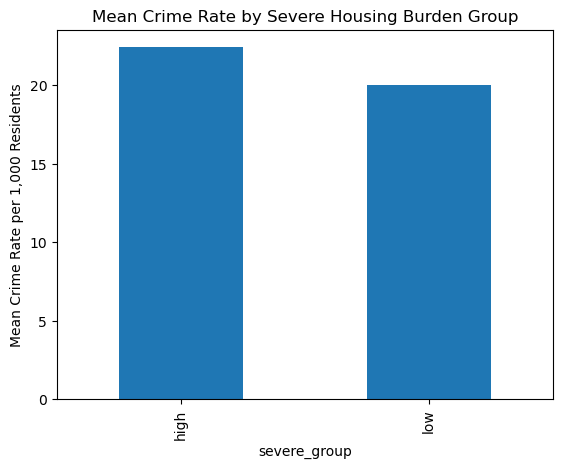

In [ ]:
group_mean = df.groupby("severe_group")["crime_rate"].mean()

group_mean.plot(kind="bar")
plt.ylabel("Mean Crime Rate per 1,000 Residents")
plt.title("Mean Crime Rate by Severe Housing Burden Group")
plt.show()

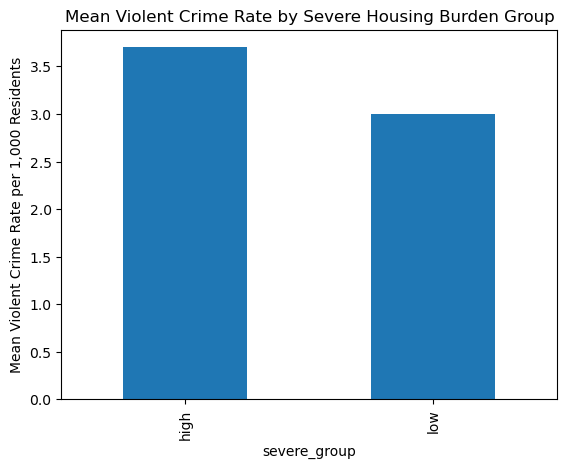

In [ ]:
violent_group = df.groupby("severe_group")["violent_rate"].mean()

violent_group.plot(kind="bar")
plt.ylabel("Mean Violent Crime Rate per 1,000 Residents")
plt.title("Mean Violent Crime Rate by Severe Housing Burden Group")
plt.show()

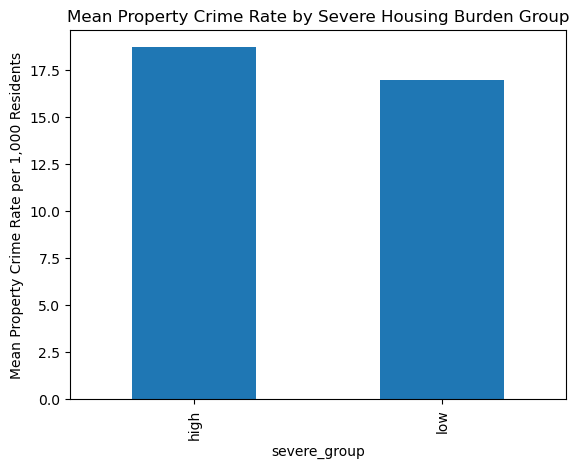

In [ ]:
property_group = df.groupby("severe_group")["property_rate"].mean()

property_group.plot(kind="bar")
plt.ylabel("Mean Property Crime Rate per 1,000 Residents")
plt.title("Mean Property Crime Rate by Severe Housing Burden Group")
plt.show()

## 13. Statistical Comparison

Welch's t-tests are used as an exploratory statistical check to compare mean crime rates between high- and low-burden tracts. This helps evaluate whether the observed mean differences are statistically distinguishable.

In [ ]:
for col in ["crime_rate", "property_rate", "violent_rate"]:
    high = df[df["severe_group"] == "high"][col].dropna()
    low = df[df["severe_group"] == "low"][col].dropna()
    result = ttest_ind(high, low, equal_var=False)
    print(f"{col}: t-statistic = {result.statistic:.3f}, p-value = {result.pvalue:.4f}")

crime_rate: t-statistic = 0.927, p-value = 0.3550
property_rate: t-statistic = 0.783, p-value = 0.4345
violent_rate: t-statistic = 1.404, p-value = 0.1621


## 14. Prepare Map Data

The ACS and crime data are merged back to census tract geometries for mapping. The map is filtered to Prince George's County tracts.


In [ ]:
tracts_pg = tracts[tracts["GEOID"].astype(str).str.startswith("24033")].copy()
map_df = tracts_pg.merge(df, on="GEOID", how="left")

## 15. Map Socioeconomic Context

These maps show the spatial distribution of median household income and renter housing burden. Income and housing burden are related but not identical. This project focuses on renter housing burden because income alone does not fully capture housing cost pressure.


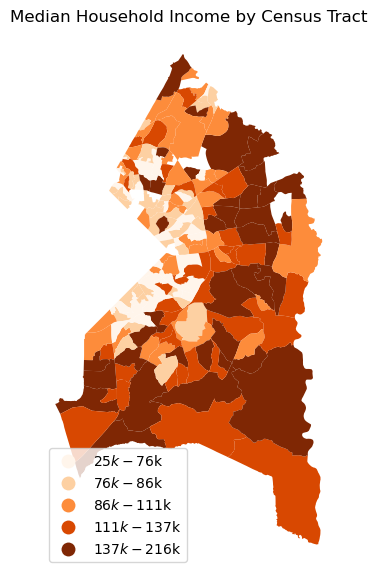

In [ ]:
map_df["income_num"] = pd.to_numeric(
    map_df["Median_household_income"],
    errors="coerce"
)

map_df["income_group"] = pd.qcut(
    map_df["income_num"],
    q=5,
    labels=[
        "$25k - $76k",
        "$76k - $86k",
        "$86k - $111k",
        "$111k - $137k",
        "$137k - $216k"
    ],
    duplicates="drop"
)

fig, ax = plt.subplots(figsize=(7, 7))
map_df.plot(
    column="income_group",
    cmap="Oranges",
    legend=True,
    legend_kwds={"loc": "lower left"},
    ax=ax
)
plt.title("Median Household Income by Census Tract")
plt.axis("off")
plt.show()

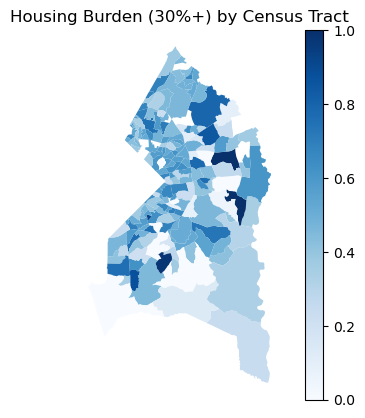

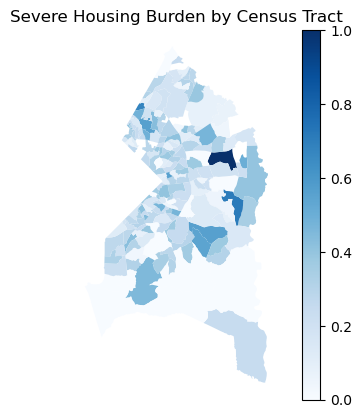

In [ ]:
map_df.plot(column="pct_renter_burden_30plus", cmap="Blues", legend=True)
plt.title("Housing Burden (30%+) by Census Tract")
plt.axis("off")
plt.show()

map_df.plot(column="pct_renter_severe_burden", cmap="Blues", legend=True)
plt.title("Severe Housing Burden by Census Tract")
plt.axis("off")
plt.show()

## 16. Map Crime Rates

The following maps show tract-level total crime, violent crime, and property crime rates per 1,000 residents.


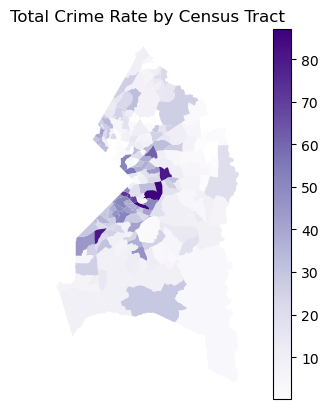

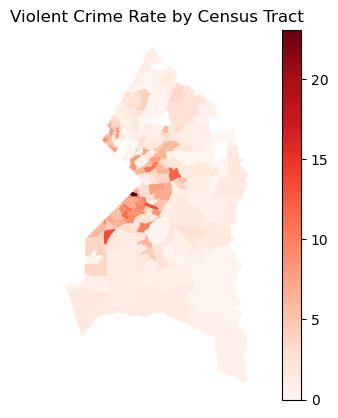

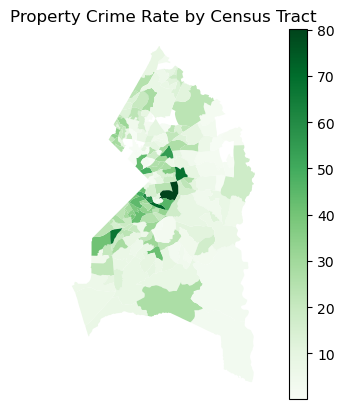

In [ ]:
map_df.plot(column="crime_rate", cmap="Purples", legend=True)
plt.title("Total Crime Rate by Census Tract")
plt.axis("off")
plt.show()

map_df.plot(column="violent_rate", cmap="Reds", legend=True)
plt.title("Violent Crime Rate by Census Tract")
plt.axis("off")
plt.show()

map_df.plot(column="property_rate", cmap="Greens", legend=True)
plt.title("Property Crime Rate by Census Tract")
plt.axis("off")
plt.show()

## 17. Overlap Map: Housing Burden and Crime Rate

To directly examine spatial overlap, tracts are classified into four groups based on whether severe housing burden and crime rate are above or below their median values. The **high_high** group identifies tracts with both high severe housing burden and high crime rate.


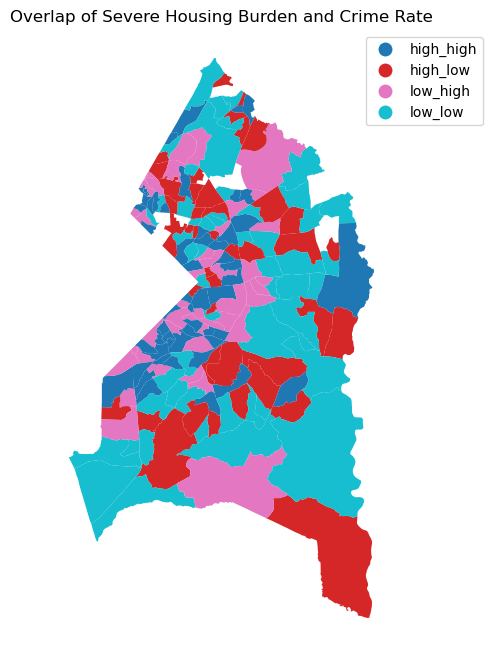

In [ ]:
crime_threshold = df["crime_rate"].median()

df["crime_group"] = df["crime_rate"].apply(
    lambda x: "high" if x > crime_threshold else "low"
)

df["overlap_group"] = df["severe_group"] + "_" + df["crime_group"]

# Merge the overlap classification back to PG County tract geometries
map_overlap = tracts_pg.merge(
    df[["GEOID", "overlap_group"]],
    on="GEOID",
    how="left"
)

fig, ax = plt.subplots(figsize=(6, 8))
map_overlap.plot(
    column="overlap_group",
    legend=True,
    ax=ax,
    legend_kwds={"bbox_to_anchor": (1.3, 1)}
)
plt.title("Overlap of Severe Housing Burden and Crime Rate")
plt.axis("off")
plt.show()

## 18. Interpretation

The results suggest that census tracts with higher severe renter housing burden tend to show higher mean crime rates. This pattern appears for total crime, violent crime, and property crime, with the largest difference appearing for property crime. The overlap map further shows that some census tracts experience both high severe housing burden and high crime rates, suggesting possible spatial concentration of neighborhood disadvantage.

These findings indicates that housing burden does not necessarily cause crime; both may be shaped by broader factors such as income inequality, housing instability, policing patterns, neighborhood investment, and historical segregation.

## 19. Limitations and Smart City Considerations

This analysis has several limitations. First, the crime dataset includes incidents reported through the Prince George's County Police Department. Some municipalities within the county maintain separate police departments, meaning some incidents may be underrepresented in this dataset. As a result, some tract-level crime rates may be underestimated.

Second, crime data reflect reported incidents, not all criminal activity. Reporting patterns and policing practices may vary across neighborhoods.

From a smart city perspective, spatial data can help identify communities facing multiple disadvantages. However, crime maps can also reinforce stigma if they are interpreted without social context. Data-driven planning should therefore focus on equitable support, investment, and community needs rather than surveillance or punitive responses.

## 20. Reproducibility Notes

To reproduce this analysis, place the following files in the same directory as this notebook:

1. `ACSDTY2024_tract.xlsx`
2. `PG_Crime_Incidents_2024.xlsx`
3. `tl_2024_24_tract/` folder containing the TIGER/Line tract shapefile components

The notebook can then be run from top to bottom.
